## 背景
  某电商公司非常注重自己的落地页设计，希望通过改进设计来提高转化率。以往该公司全年转化率平均在13%左右，现在希望设计的新页面能够带来更高的转化率，希望新页面的转化率能有2%的提升，达到15%。在正式推出新页面之前，该公司希望通过AB测试在小范围的用户中进行测试，以确保新页面的效果能够达到预期目标

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.stats.api as sms
#从样本数据推断总体特征
import matplotlib as mpl
plt.rcParams['font.sans-serif']=['SimHei']

## 最小样本数的求取

In [2]:
#计算效应大小,该函数用于比较两个比例之间的标准化差异，效应量越大，所需要的样本量越小，影响更显著
#效应量是对差异大小的标准化量化，显著性（p值）回答有没有差异，效应量回答差异有多大
effect_size=sms.proportion_effectsize(0.13,0.15)
effect_size

np.float64(-0.0576728617308947)

In [3]:
required_n=sms.NormalIndPower().solve_power(
    effect_size,
    power=0.8,#1-β
    alpha=0.05,
    ratio=1#对照组与实验组样本比例
)

In [4]:
required_n

4719.4740575998185

In [5]:
np.ceil(required_n)

np.float64(4720.0)

综合样本量和日活来计算样本周期，假如落地页以往每天日活为50人，那试验周期需要的天数最小为17天

## 数据预处理

In [6]:
data=pd.read_csv(r"D:\jupyter name\数据\ab_data.csv")

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


In [8]:
df1=data[(data['group']=='control')&(data['landing_page']=='old_page')]
df2=data[(data['group']=='treatment')&(data['landing_page']=='new_page')]

In [9]:
df1.value_counts('group'),df2.value_counts('group')

(group
 control    145274
 Name: count, dtype: int64,
 group
 treatment    145311
 Name: count, dtype: int64)

In [10]:
data.duplicated().sum()

np.int64(0)

In [11]:
data['user_id'].duplicated().sum()

np.int64(3894)

In [12]:
data[data['user_id'].duplicated()]['user_id']

2656      698120
2893      773192
7500      899953
8036      790934
10218     633793
           ...  
294308    905197
294309    787083
294328    641570
294331    689637
294355    744456
Name: user_id, Length: 3894, dtype: int64

In [13]:
repeat_id=data[data['user_id'].duplicated()]['user_id']
df=data[~data['user_id'].isin(repeat_id)]

## SRM检验
检查分流系统是否正常

In [14]:
group_counts=df['group'].value_counts()
control_count=group_counts['control']
treatment_count=group_counts['treatment']
print(f"对照组人数:{control_count},实验组人数:{treatment_count}")

对照组人数:143293,实验组人数:143397


In [15]:
total_count=len(df)
expected=[total_count/2,total_count/2]
observed=[control_count,treatment_count]
chisq,p_value_srm=stats.chisquare(f_obs=observed,f_exp=expected)
#chisq卡方统计量，用来衡量实际分组人数与与预期分组人数之间的差异程度,p_value_srm，p值核心判断指标，
#p值为0.8459说明实际分组的微小偏差是随机导致，因此，SRM检验是通过的

In [16]:
if p_value_srm<0.01:
    print("SRM不通过,分组存在显著偏差")
else:
    print("SRM通过,分组比例正常")

SRM通过,分组比例正常


## 假设检验

In [17]:
convert_old=df[df['group']=='control']['converted'].sum()
convert_new=df[df['group']=='treatment']['converted'].sum()
n_old=df[df['group']=='control']['converted'].count()
n_new=df[df['group']=='treatment']['converted'].count()
prob_old=convert_old/n_old
prob_new=convert_new/n_new
print(f"旧页面转换率{prob_old:.2%}")
print(f"新页面转换率{prob_new:.2%}")
lift=(prob_new-prob_old)/prob_old
print(f'相对提升率{lift:.2%}')

旧页面转换率12.02%
新页面转换率12.29%
相对提升率2.30%


In [103]:
#Z_Test(双尾测试)
z_score, p_value = sm.stats.proportions_ztest([convert_new, convert_old], [n_new, n_old], alternative='two-sided')
print(f"z值为{z_score:.4f}")
print(f"p值为{p_value:.4f}")
if p_value<0.05:
    print("结果显著，拒绝原假设")
else:
    print("结果不显著，接受原假设")

z值为2.2654
p值为0.0235
结果显著，拒绝原假设


## 置信区间

In [104]:
(lower_con, lower_treat), (upper_con, upper_treat) = proportion_confint(
    [convert_old, convert_new],
    [n_old, n_new],
    alpha=0.05,
    method='normal'
)
print(f"对照组 95%置信区间 : [{lower_con:.4%}, {upper_con:.4%}]")
print(f"实验组 95%置信区间 : [{lower_treat:.4%}, {upper_treat:.4%}]")

对照组 95%置信区间 : [11.8490%, 12.1857%]
实验组 95%置信区间 : [12.1239%, 12.4638%]


## 监控图

In [105]:
df['timestamp']=pd.to_datetime(df['timestamp'])
df['date']=df['timestamp'].dt.date
daily_data=df.groupby(['date','group'])['converted'].agg(['sum','count'])

C:\Users\86150\AppData\Local\Temp\ipykernel_15644\372800061.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['timestamp']=pd.to_datetime(df['timestamp'])
C:\Users\86150\AppData\Local\Temp\ipykernel_15644\372800061.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date']=df['timestamp'].dt.date


In [117]:
daily_data=daily_data.drop('daily_rate',axis=1)

In [118]:
daily_data.columns=['converted_daily','total_daily']
daily_data['daily_rate']=daily_data['converted_daily']/daily_data['total_daily']

In [120]:
daily_data = daily_data.sort_values(['group', 'date']) # 排序很关键

# 计算累计转化数和累计总人数
daily_data['cum_converted'] = daily_data.groupby('group')['converted_daily'].cumsum()
daily_data['cum_total'] = daily_data.groupby('group')['total_daily'].cumsum()

# 计算累计转化率
daily_data['cum_rate'] = daily_data['cum_converted'] / daily_data['cum_total']

# 查看一下数据结构
print(daily_data.head())

                    converted_daily  total_daily  daily_rate  cum_converted  \
date       group                                                              
2017-01-02 control              354         2813    0.125844            354   
2017-01-03 control              738         6494    0.113643           1092   
2017-01-04 control              787         6481    0.121432           1879   
2017-01-05 control              780         6330    0.123223           2659   
2017-01-06 control              750         6518    0.115066           3409   

                    cum_total  cum_rate  
date       group                         
2017-01-02 control       2813  0.125844  
2017-01-03 control       9307  0.117331  
2017-01-04 control      15788  0.119014  
2017-01-05 control      22118  0.120219  
2017-01-06 control      28636  0.119046  


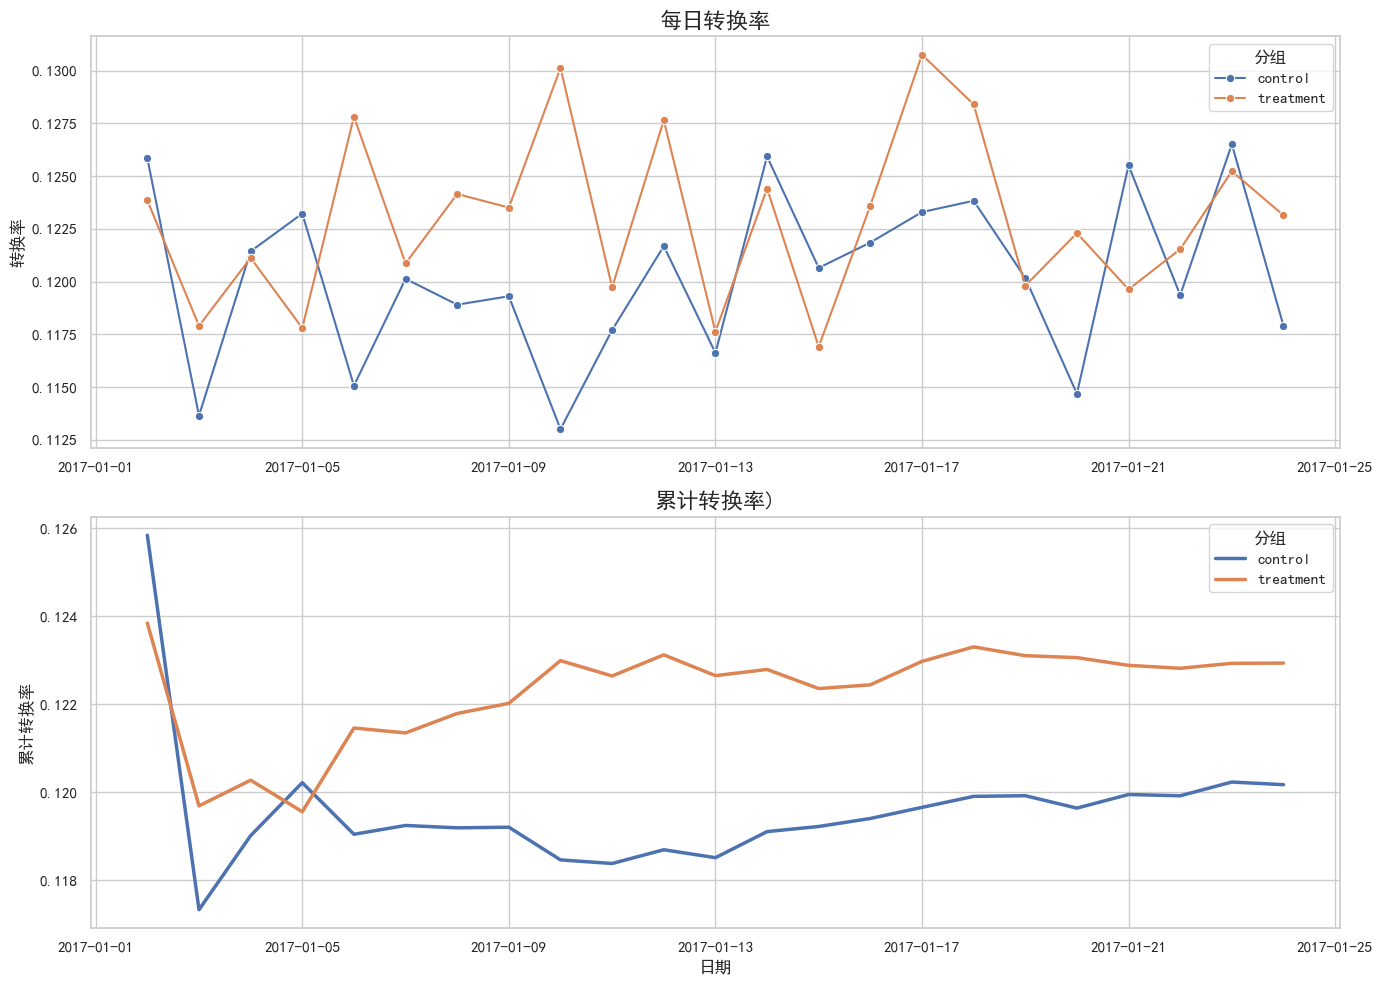

In [131]:
# 设置绘图风格
sns.set(style="whitegrid")
plt.figure(figsize=(14, 10))
plt.rcParams['font.sans-serif'] = ['SimHei']
# --- 图 1: 每日转化率 (Daily Conversion Rate) ---
# 作用：检查数据质量，看有没有哪一天数据崩了
plt.subplot(2, 1, 1)
sns.lineplot(data=daily_data, x='date', y='daily_rate', hue='group', marker='o')
plt.title('每日转换率', fontsize=16)
plt.ylabel('转换率')
plt.xlabel('') # 上面的图不需要X轴标签，显得干净
plt.legend(title='分组')

# --- 图 2: 累计转化率 (Cumulative Conversion Rate) ---
# 作用：这是决策图。看两条线是否逐渐平稳并拉开差距
plt.subplot(2, 1, 2)
sns.lineplot(data=daily_data, x='date', y='cum_rate', hue='group', linewidth=2.5)
plt.title('累计转换率)', fontsize=16)
plt.ylabel('累计转换率')
plt.xlabel('日期')
plt.legend(title='分组')

# 调整布局防止重叠
plt.tight_layout()
plt.show()